<a href="https://colab.research.google.com/github/TaniLB-bit/biogas-report/blob/main/Lesson_6_Data_Structures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 6: Data Structures (Dictionaries, Sets, and Tuples)

Welcome back! Today we're going to learn about some new data structures in Python (Dictionaries, Sets, and Tuples).

## Agenda

Section Content   | Expected Time
-------|------------------------
Lesson Goals & Warm-up | 5 min
Recap | 15-20 min
Data Structures: High-Level | 5 min
Why we need dictionaries | 10-15 min
Overview of dictionaries | 15-20 min
Break | 10 min
Practice dictionaries | 10-20 min
Sets & Tuples | 10 min
Practice: Sets & Tuples | 10 min
Wrap-up | 5 min

## Warm-up questions
- Why are functions useful?
- When should you use a for loop vs. a while loop?
- How do we index into lists?
- Any questions from last class?


## Review

In the past few sessions we learned a lot about pythons basic operations. We learnt about different datatypes, how to use variables and how to deal with input and output. We learnt how to change the control flow trough conditionals and loops and how to structure our program more clearly with functions.

With all the python commands that we have learnt so far, we are in theory able to build basically every program and algorithm. However, there are still some new concepts that will help us write better, faster, more readable code 😀

Here's a recap of the concepts we have seen so far, for reference. (Please spend some time reviewing this later!)

**Working with variables, Input and Output**
- we can assign a value to a variable with this syntax: `variable_name = value`
-Read input using `input()` and print output using `print()`

**Data Types**
- `Integers, Floats, Strings and Booleans`
- Lists: Last session we introduced lists. These allow us to store data in a structured way. Lists are mutable, this means we can add or remove elements from a list.
 - Elements in a list are accessed by their index (starting at 0), e.g `my_list[0]` will give me the first element in mylist.
 - Elements can be added using `.append(element)` and removed with `.remove(element)` or .pop(index).


**Conditionals and Comparisons**
- Use `if, elif, and else` to execute code based on conditions.
- Compare values using operators like `==, !=, >, <, >=, <=, is, in`.

**Functions**
- Define reusable blocks of code with `def functionName(parameters):`
- Functions can return values with return.
- Use keywords arguments if the number of arguments a function receives becomes to complex.

**Loops**
- Use for loops for iterating over a sequence (like a list or range()).
- while loops run as long as a condition is true. This can lead to loops never terminating and thus your programs gets stuck at this point forever.
- Control loop execution with
  - `break` (exit the loop)
  - `continue` (skip to the next iteration).




## 🛠️ Data Structures: High-Level
Today's session will focus on covering a few key data structures in Python.

### What is a data structure?

The term **data structure** simply refers to a container for storing data. We've already seen an example of this -- lists! Today we will cover a few more: dictionaries, sets, and tuples. Data structures are not specific to Python. These are fundamental topics in computer science theory and every programming language has versions of a few core structures.

### Why do we need different data structures?

Different data structures have different:
- intended purposes
- strengths/weaknesses

You can think of each data structure as a tool in your toolbelt. Choosing the right tool for a task makes it easier to solve. For instance, you can try to use a screwdriver to hit a nail into a piece of wood, but it'll be much harder than trying to do this using a hammer.

### How do we choose the right structure?
Try to pay attention to the properties of the different structures, and trying to identify which of those would be useful when solving problems.

Of course, you will build this intuition by **practicing and writing lots of code**!

We will take a look at a practical example of why it might be useful to use a different data structure than a list.


### Illustration: Why we need Dictionaries
Imagine the following scenario: someone hires you to build an online shop. Customers can register on the website with their name and age. You have to store this data such that it can be accessed later.

Let's look at some approaches to solving this problem.



#### Approach 1: Using Two Lists
Track the customer names and ages in separate lists, where index `i` corresponds to customer `i`.

In [ ]:
customer_names = []
customer_ages = []

def add_customer(name, age):
    customer_names.append(name)
    customer_ages.append(age)

add_customer("Peter", 22)
add_customer("Aleksandra", 35)
add_customer("Laiyan", 52)
add_customer("Ruven", 40)

print(customer_names)
print(customer_ages)

['Peter', 'Aleksandra', 'Laiyan', 'Ruven']
[22, 35, 52, 40]


In [ ]:
def get_customer_age(name):
  # First get the index of the name in the list
  index_of_name = customer_names.index(name)
  # use this index to get the corresponding age
  age =  customer_ages[index_of_name]
  return age

age_ruven = get_customer_age("Ruven")
print(age_ruven)

40


Your companies products turn out to be a huge success and within a few months you have millions of new users!!!🎉 👏

However, you are now suddenly receiving complaints from customers that the shop is very slow sometimes. You take a look at your code and it seems that the more users there are, the slower your program becomes...

In [ ]:
import time

print("When we only had 3 users...")
time_before = time.time()
age_ruven = get_customer_age("Ruven")
time_after = time.time()
few_users_time_list = time_after - time_before
print(f"It took {(few_users_time_list)*1000}ms to get Ruven's age")

# These new users with their age are now all stored in customer_names and customer_ages
# Don't worry about the create_fake_names function --
# it is used to generate 20million distinct, fake user entries so this might take a few seconds.
def create_fake_names(amount):
    return [str(i) for i in range(amount)]

def create_fake_ages(amount):
    return [1 for i in range(amount)]

customer_names = create_fake_names(20000000)
customer_ages = create_fake_ages(20000000)

add_customer("Ruven", 40)
print("Now with 20 million users...")
time_before = time.time()
age_ruven = get_customer_age("Ruven")
time_after = time.time()
time_list = time_after - time_before
print(f"It takes {time_list * 1000}ms to get Ruven's age")

if time_list > few_users_time_list:
    print(f"It's now {time_list / few_users_time_list} times slower than before!")


When we only had 3 users...
It took 0.06604194641113281ms to get Ruven's age
Now with 20 million users...
It takes 322.6470947265625ms to get Ruven's age
It's now 4885.487364620939 times slower than before!


In [ ]:
# How does list.index() work at a high-level?
# Lets take a look at what happens you call list.index()
# Do you know how many comparisons your program has to make?
def get_customer_index(name):
    index_counter = 0
    for customer_name in customer_names:
        if customer_name == name:
            return index_counter
        else:
            index_counter += 1

index_ruven = get_customer_index("Ruven")
age_ruven = customer_ages[index_ruven]
print(age_ruven)

##### 💡 Check-in Question
Why do you think it takes longer to get a customer's data, the more data we have?

#### Approach 2: Using Nested Lists
We can use nested lists in order to avoid having to deal with two separate lists and allowing us to keep user and age stored directly associated with each other. What do you think - will it be faster or slower than Approach 1?

In [ ]:
# Each element in our database is a list consisting of two elements: The first being the customer_name and the second being the age.
# For example one element in the database could be this list: ["Naomi", 33]
database = [
    ["Naomi", 33],
    ["Louis", 62]
]

def add_customer(name, age):
    new_entry = [name, age]
    database.append(new_entry)

add_customer("Peter", 22)
add_customer("Aleksandra", 35)
add_customer("Laiyan", 52)
print(database)


#### Approach 3: ✨ Dictionaries ✨
While Approach 2 is a bit nicer to read and has related data stored in the same place, it suffers from the same problems as Approach 1. Again we have to check every element in the list whether it is the name we are looking for, resulting in high runtimes when the element happens to be towards the end of the list. Luckily the concepts of dictionaries exists to solve this problem! :)

In [ ]:
# Dictionary comprehension, similar to list comprehension but for creating dicts from some iterable.
customers_dictionary = {name: age for name, age in zip(customer_names, customer_ages)}

def get_customer_age(name):
    return customers_dictionary[name]

t = time.time()
age_ruven = get_customer_age("Ruven")
time_dict = time.time() - t
print(f"It took {time_dict*1000}ms to get Ruven's age in a database of 20million users")

In [ ]:
print("Time to get the age from List (ms): ", time_list*1000)
print("Time to get the age from Dictionary (ms): ", time_dict*1000)
print("Speedup: x", int(time_list/time_dict) )

## Dictionaries

### Main properties
- **unordered\*** (Depending on Python version -- ordered since Python 3.7, but we don’t usually use dictionaries for the reason that they are ordered.)
- **mutable**
- maps key --> value
- optimized to look up a `value` by its `key` very quickly, regardless of how many entries are stored in the dictionary

Dictionary structure: `{key: value}`

### When to use a dictionary
- need fast access to values by key
- organize data (values) by name (key) (this can improve code readability)

### Working with dictionaries

In [ ]:
# Creating dictionaries

# Two ways to create an empty dictionary:
empty_dict = {}
empty_dict = dict()


# Or initialize with key:value pairs
english_to_german = {
    "hello": "hallo",
    "world": "welt",
}
# print(english_to_german)

todo = {
    "title": "Groceries",
    "duration": 15,
    "done": False,
}
print(todo)

todo_list = [
    {
        "title": "Groceries",
        "done": False,
    }, {
        "title": "Homework",
        "done": True,
    }
]

print(todo_list)

{'title': 'Groceries', 'duration': 15, 'done': False}
[{'title': 'Groceries', 'done': False}, {'title': 'Homework', 'done': True}]


In [ ]:
# Retrieving data

# In general we have a given key and want to get the data corresponding to this key
# similar to list indexing, but we use the `key`
print(english_to_german["hallo"]) # "hallo"

# Or save the retrieved value it in a variable and use later:
greeting_german = english_to_german["hello"]

name = "Aleksandra"
print(greeting_german + ", " + name + "!")

KeyError: 'hallo'

In [ ]:
# What happens if you try to access a key that is not in the list?
english_to_german["apple"]

KeyError: 'apple'

In [ ]:
# There are multiple possibilites to ensure you do not receive this error:
# 1. First ensure the key is in the dictionary before accessing it,
#    using the membership operator `in`.
if "apple" in english_to_german:
    print(english_to_german["apple"])
else:
    print("Sorry this key is not in the dictionary")

# 2. Using the in-built .get() method. This is a safer way to access dictionaries,
#    that returns None if the key is not in the dictionary
print(english_to_german.get("hello"))
print(english_to_german.get("apple"))

Sorry this key is not in the dictionary
hallo
None


In [ ]:
# You can also add values to the dictionary.
english_to_german["apple"] = "apfeel"
english_to_german.update({"bye": "tschoss"})

print(english_to_german)

In [ ]:
# Oops, we made a few typos above!
# We can overwrite it by assigning a new value to the existing key.
english_to_german["apple"] = "apfel"
english_to_german.update({"bye": "tschüss"})
print(english_to_german) # the old values have been overwritten

In [ ]:
# Removing key-value pairs from a dictionary
removed_value = english_to_german.pop("apple")
print(english_to_german)
print("Removed value:", removed_value)

### Dictionary keys

Anything **immutable** (or more properly, which can be hashed) can be a key of a dictionary

E.g.
- numbers
- strings
- tuples
- functions (!!! -- though you probably won't want to do this very often)

But not:
- lists
- dictionaries themselves

In [ ]:
a = {1: "a", 2: "b"} # ok
b = {"a" : 1, "b": 2} # ok

def mult_2(x):
    return x*2

manual = {mult_2: 'This function multiplies the numeric input by 2'} # ok

print(manual[mult_2]) # retreive the value stored

In [ ]:
d = {[1, 2, 3]: 3} # TypeError
e = {{'a': 1}: 'a'} # TypeError

**Bonus Information**: You might wonder what "hashing means" and why some types are hashable whilst others are not. In fact, the dictionary data structure is more generally called a _hash table_ or _hash map_ in Computer Science and is used in many different programming languages. **For the moment this is not essential for the class**, but if you are interested in understanding the internals of how dictionaries work and why they are able to work so quickly, feel free to read up more on this, however it might be quite challenging at this stage:
- [CMU Lecture](https://www.cs.cmu.edu/~15110-s20/slides/week8-1-dictionaries.pdf)
- [Medium Link](https://medium.com/@arjun.darji/understanding-hash-tables-in-python-dictionaries-e6f16c612e95#:~:text=In%20Python%2C%20dictionaries%20use%20hash,in%20the%20underlying%20data%20structure)
- [Towards Data Science Link](https://towardsdatascience.com/what-the-hash-d678538b313)


### Dictionary values
Values do not have the same hashing restriction. That means you can have a dictionary that maps hashable keys to lists and dictionaries.

We call dictionaries within dictionaries "nested dictionaries".

In [ ]:
# No TypeErrors this time ;)
d = {
    "list1": [1, 2, 3],
    "dict1": {"key": "value"}
}
print(d)

{'list1': [1, 2, 3], 'dict1': {'key': 'value'}}


In [ ]:
# Nested dictionaries (dictionary in a dictionary)
# This allows for much greater flexibility and allows us to represent more complex data.
english_dictionary = {
    'hello': {
        'italian': 'ciao',
        'spanish': 'hola'
        },
    'world' :  {
        'italian': 'mondo',
        'spanish': 'mundo'
        }
    }

hello_translations = english_dictionary["hello"]
hello_in_spanish = hello_translations["spanish"]
print(hello_in_spanish)

# another way of doing this (without storing an intermediate variable):
print(english_dictionary["hello"]["spanish"])


hola
hola


### Iterating through dictionaries
For a dictionary `d`, We can use a few other functions to retrieve:
- keys --> `d.keys()`
- values --> `d.values()`
- (key, value) pairs --> `d.items()`

These functionas are very useful for iterating through dictionaries.

In [ ]:
# get the dictionary keys using `.keys()`
print("Keys:", english_dictionary.keys())

# get all the dictionary values using `.values()
print("Values:", english_dictionary.values())

# get (key, value) pairs using `.items()`
print("Items:", english_dictionary.items())

Keys: dict_keys(['hello', 'world'])
Values: dict_values([{'italian': 'ciao', 'spanish': 'hola'}, {'italian': 'mondo', 'spanish': 'mundo'}])
Items: dict_items([('hello', {'italian': 'ciao', 'spanish': 'hola'}), ('world', {'italian': 'mondo', 'spanish': 'mundo'})])


In [ ]:
# Iterating through dictionaries
for key, value in english_dictionary.items():
    print("Key:", key, "- Value:", value)

Key: hello - Value: {'italian': 'ciao', 'spanish': 'hola'}
Key: world - Value: {'italian': 'mondo', 'spanish': 'mundo'}


## Practice Dictionaries

### Fundamentals
Use the next 10 minutes to try out working with dictionaries. Once you are finished, go through the answers with your breakout rooms.

In [ ]:
# TODO: Create a dictionary named `fruits` and add the following key-value pairs:
# "apple" with a value of "red", "banana" with a value of "yellow", and "grape" with a value of "purple".


In [ ]:
# TODO: Access & print the value associated with the key "banana" in the fruits dictionary.

In [ ]:
# TODO: Change the value associated with the key "grape" to "green".

In [ ]:
# TODO: Add a new key-value pair to the fruits dictionary: "orange" with a value of "orange".

In [ ]:
# TODO: Add another fruit "kiwi" with the value "gold" to the fruits dictionary using the .update() method

In [ ]:
# TODO: Remove "grape" from the dictionary

In [ ]:
# The next few practice tasks will use this dictionary.
# TODO: Make sure to run this cell first! No code changes needed :)
state_abbreviations = {
    "Baden-Württemberg": "BW",
    "Bavaria": "BY",
    "Berlin": "BE",
    "Brandenburg": "BB",
    "Bremen": "HB",
    "Hamburg": "HH",
    "Hesse": "HE",
    "Lower Saxony": "NI",
    "Mecklenburg-Vorpommern": "MV",
    "North Rhine-Westphalia": "NW",
    "Rhineland-Palatinate": "RP",
    "Saarland": "SL",
    "Saxony": "SN",
    "Saxony-Anhalt": "ST",
    "Schleswig-Holstein": "SH",
    "Thuringia": "TH",
}

In [ ]:
# TODO: Print out the abbreviation for Berlin, by accessing this in the `state_abbreviations` dictionary.

In [ ]:
# TODO: Print out the keys in `state_abbreviations` using a dictionary method.

In [ ]:
# TODO: Write a for loop that iterates through the items in `state_abbreviations`
# and prints each state with its abbreviation, e.g. "Berlin, BE"

### Intermediate
This practice is a litte more challenging and requires you to apply dictionaries in different use cases. The example focuses on building a dictionary for storing and organizing students' information (called `students`). Each of the steps builds on the previous one.

In [ ]:
# TODO: Create an empty dictionary called `students`.


In [ ]:
# TODO: For the first student, add a key-value pair to `students` dictionary where:
# - the key is an example student's name: "John".
# - the value is another dictionary containing the keys age (-> value 15) and
#   grades (-> value [88, 92, 79])


In [ ]:
# TODO: Repeat the steps above to add a second student, "Emma", with age 17, and grades [95, 80, 82].


In [ ]:
# TODO: Add a third student, "Mike". Set his age to 16, and grades to [78, 85, 90].


In [ ]:
# TODO: Retrieve and print the age of Emma.

In [ ]:
# TODO: Calculate the Average Grade of John by following these steps:
# 1. Retrieve the list of grades for John.
# 2. Calculate the average of these grades and print the result.
#  (Hint: the average is computed by summing up all grades and dividing by the amount of grades,
#   so first use a for loop to sum up all grades in the list and then divide them by the number of entries in the list).



In [ ]:
# TODO: Find the average age of all students
# Hint: The .values() method will be helpful here


In [ ]:
# TODO: Print the names of all students older than 16
# Hint you might need the .items() method and will have to use some conditional expressions


## Sets
Sets in Python are a data structure designed after the notion of sets in mathematics.

### Main properties
- **unordered**: do not record element position or order of insertion, so do not support indexing or slicing
- **mutable**: can add/remove elements in a set
- **uniqueness**: every element in a set is unique (no duplicates)

### When to use a set
- **membership testing**: using the membership operator (`in`) --> check if an element is contained in the set
- **deduplicating**: removing repeated elements from a sequence (identifying unique elements)
- **performing mathematical set operations** like unions, intersections, and set differences



In [ ]:
# Creating an empty set
empty_set = set()
# Note: you cannot create an empty set with {},
# since this is interpreted as an empty dictionary!

# Creating a set with contents
my_set = {'a', 'b', 'c', 'b', 'a',}
print(my_set)

# Creating a set from a list
my_list = [3, 1, 2, 3, 3, 4, 5, 3]
my_set_from_list = set(my_list)
print(my_set_from_list)  # Duplicates from the list are removed

{'a', 'b', 'c'}
{1, 2, 3, 4, 5}


In [ ]:
# Unlike lists, sets are unordered and we are therefore not able to access elements in a set by index.
# We can use the `in` operator to check for membership
my_set = {1, 2, 3, 4, 5}

# Note: `assert` is useful for writing tests; it will throw an error if the condition is false.
# assert 100 in my_set
print(3 in my_set)
#assert 6 not in my_set

True


In [ ]:
my_set = {1, 2, 3}

# Adding elements
my_set.add(4)
print(my_set)

# Adding multiple elements
my_set.update([5, 6])
print(my_set)

# Removing elements
my_set.remove(6)  # Raises a KeyError if the element is not found
print(my_set)

# my_set.discard(9)  # Does NOT raise an error if the element is not found
# print(my_set)
# my_set.discard(5)
# print(my_set)

{1, 2, 3, 4}
{1, 2, 3, 4, 5, 6}
{1, 2, 3, 4, 5}


Mathematical set operations are one of the strengths of sets in python. Given two sets you can find out, whether elements are present in both sets, combine them and much more. An explanation of these operations is visualized in this picture:

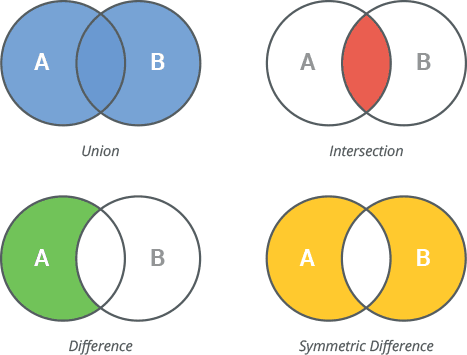

In [ ]:
a = {1, 2, 3, 4}
b = {3, 4, 5, 6}

# Union (all values)
print("Union")
print(a | b)  # {1, 2, 3, 4, 5, 6}


# Intersection (shared values)
print("Intersection")
print(a & b)  # {3, 4}

# Difference (Subtraction)
print("Difference")
print(a - b)  # {1, 2}

# Symmetric Difference (ignore shared values)
print("Symmetric Difference")
print(a ^ b)  # {1, 2, 5, 6}

Union
{1, 2, 3, 4, 5, 6}
Intersection
{3, 4}
Difference
{1, 2}
Symmetric Difference
{1, 2, 5, 6}


## Tuples
Tuples in Python are basically immutable lists.

### Main properties
- **ordered**: support indexing or slicing
- **immutable**: cannot add/remove elements to the structure

### When to use a tuple
- storing data that should not be modified (ex: constants, configurations)
  - faster & more memory efficient- compared to lists due to immutability
- returning multiple values from functions, or data that "goes together", for example RGB-Color Values `(r, g, b)` or mathematical coordinates `(x, y)`


In [ ]:
# Creation.
empty_tuple = ()
empty_tuple = tuple()

# Tuples can have duplicate elements and contain mixed types
my_tuple = (1, "two", 3.0, 4, 4)
print(my_tuple)


def func1():
  return (1, 'two', True)

def func2():
  return [1, 'two', False]

print(func1())
print(func2())

(1, 'two', 3.0, 4, 4)
(1, 'two', True)
[1, 'two', False]


In [ ]:


# Accessing Elements (same as list indexing)
print(my_tuple[2])

3.0


In [ ]:
# Immutability: The contents of a tuple can not be changed after creation.
my_tuple[2] = 6 # This will cause a TypeError

In [ ]:
# Tuple Methods (basically the same as for lists)
print(my_tuple.count(4)) # Counts the occurances of a given element

print(my_tuple.index("two")) # Returns the index of the first occurance of an element. Similar like list.index()

In [ ]:
# Tuple Slicing
# Just as with lists we can slice tuples, to get a subset of this tuple
print(my_tuple[1:4]) # [from_index:to_index], however the to_index is not included (exclusive)

In [ ]:
# Tuple packing and unpacking
# Another way of creating a tuple -- listing data values or variables without the parentheses ()
new_tuple = 10, 11, 12
print(new_tuple)

x = 5
y = 6
s = "asdf"
new_tuple = x, y, s
print(new_tuple)

In [ ]:
# We can then use a similar principle to unpack a tuple
# This allows us to assign every value from the tuple to a specific variable and makes our code easier to understand
my_file = ("image10", "jpg", 21)
file_name, file_type, file_size = my_file
print(file_type)
print(file_size)


## Practice Sets and Tuples (Fundamentals)

Use the remaining time to practice using sets and tuples. If you finish early, you can start working on the homework.


In [ ]:
# TODO: Create a set containing the numbers 1, 2, 3 and 4 and save it in a variable

In [ ]:
# TODO: Write an assert statement (use `assert` function) stating that 2 is in the set

In [ ]:
numbers = [15,8,14,8,13,19,5,22,12,23,15,16,29,29,22,7,18,1,10,9,35,10,13,11,26,19,6,29,1,1,40,23,24,32,17,28,4,20,32,11,10,35,23,32,9,14,8,25,26,11]

# Above is a list with 50 elements. Some of these are duplicates.
# TODO: Deduplicate the list (create a new data structure with unique values).


In [ ]:
# TODO: Find out how many duplicates were in the list
# Hint: use the `len` function, which tells you the length of iterables.
#   You can find out how many elements were in the initial list vs. the deduplicated version.


In [ ]:
trees = {"oak", "pine", "birch", "spruce", "maple"}

# TODO: use a for loop to iterate through and print each element in the set `trees`


In [ ]:
# You are given the ids of users in two systems as two lists.
users_system1 = [1, 2, 3, 4, 5, 89, 65]
users_system2 = [3, 70, 65, 23, 7, 122, 22]

# TODO: Find out how many users exist in both systems
#  (e.g. element is in both systems 1 and 2)


# TODO: Find out how many unique users exist in total across both systems
#  (e.g. user is in either system 1 or 2)
# Hint: Convert the lists to sets first and take a look at the set operations discussed above



In [ ]:
# TODO: Create a tuple named colors containing the strings "red", "green", and "blue".

# TODO: Print the first and last color in the tuple.


In [ ]:
# TODO: Create a tuple named point with two elements, 10 and 20, representing x and y coordinates respectively.

# TODO: Unpack the point tuple into two variables, x and y, and print their values.


In [ ]:
my_tuple = (1,3,10,2,10,7,8,10)

# TODO: Count the number of occurrences of 10 in my_tuple


In [ ]:
lst = ["three", 2.0, 1]

# TODO: Convert `lst` into a tuple and store this in variable `t`.


# TODO: Write a for loop to print out each element in `t`.
